# All-source fate preferences: linear versus literal presence

Fit mean-curvature residuals using every exclusive identity (including Unassigned) as a neighborhood source. Compare direct interaction radii of one and two hops, each with linear fraction response or literal presence, F(x)=1[x>0]. Mechanical accommodation still acts over the entire graph. No activation sharpness or local N-dependence is fitted.

The local preference is u_i=a_A+sum_B beta_AB F(x_iB); prediction solves (I+lambda L)h=u and restores the copied global baseline. One-hop exposure is the first-ring fraction; two-hop exposure is (p_1+0.5*p_2)/1.5. All identities contribute to denominators. A presence response ignores both abundance and the positive distance weight once a source is present.

For the all-linear model, Unassigned is the explicit source reference: its coefficient is zero and the other coefficients represent fraction substitutions relative to it. This resolves the exhaustive-fraction intercept ambiguity on populated rings; it does not declare Unassigned biologically inert. Regularization is applied in this declared coordinate system. Presence has all source coefficients; its all-sources-absent intercept need not be observed. Interpretation therefore focuses on supported replacements rather than intrinsic center shape.

Use the exact saved five folds, targets, baseline and preprocessing from the previous mean-curvature experiment. Penalties are selected on the same inner organoid holdout for every variant. All local coefficients and accommodation are fit jointly. Existing completed runs are preserved. Evaluation and compensation diagnostics are in simple_fate_energy_evaluation.ipynb. Pair-specific linear/presence maps are supported by the model, but automatic pair selection is deferred until these prespecified comparisons establish whether responses are identifiable.


In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import copy
import gc
import json
import shutil
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython
from IPython.display import display
from src.artifacts.bundle import load_bundle, save_bundle, graph_membership
from src.artifacts.runs import AnalysisRun
from src.artifacts.provenance import workflow_fingerprint
from src.training.coupled_fit import graph_samples
from src.training.energy_fit import fit_energy, energy_mse
from src.training.progress import TrainingProgress
torch.set_num_threads(4)
if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

## Settings
The settings below control the model grid, numerical fitting and output location. Dataset selection and preprocessing are inherited from the saved reference. Change the output folder when changing scientific settings; completed checkpoints can be resumed.


In [2]:
# Saved cohort and execution
SOURCE_RUN = 'training_results/mean_curvature_energy_training/logN_signed_half_hop_20260929_145842'  # Exact H baselines, preprocessing and outer folds.
RUN_DIR = PROJECT_ROOT/'training_results/simple_fate_energy_training/all_sources_linear_presence_20260930_153914'  # Dedicated output; retain this path to resume.
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'  # Certified float64 sparse solves.
RUN_TRAINING = True  # Train missing checkpoints; always display saved validation results.
PAIR_ACTIVATION_OVERRIDES = None  # Optional {center: {source: 'presence'/'linear'}}; add mixed_r1/mixed_r2 variants to use.

SETTINGS = dict(
    # Model scope and reference convention
    tag='all_sources_linear_presence',  # Scientific purpose of this run.
    variants=['linear_r1', 'presence_r1', 'linear_r2', 'presence_r2'],  # Activation and direct interaction radius.
    source_markers=None,  # None includes every exclusive identity and Unassigned.
    reference_marker='Unassigned',  # Linear source reference only; not an inert biological identity.
    interaction='pooled',  # Activate after combining distance-weighted ring fractions.
    exposure_kind='fractions',  # All identities contribute to ring denominators.
    ring_weights=[1., .5],  # Two-hop exposure; one-hop variants use ring 1 alone.
    pair_constraints='direct',  # Independent amplitudes; no weighted-zero constraints.
    center_response=False,  # Zero-source reference; no activation-mean subtraction.
    size_dependent=False,  # Constant center, pair and accommodation parameters.
    fixed_alpha=3.,  # Inactive legacy constructor value; presence has no threshold parameter.
    min_pair_organoids=20,  # Diagnostic support threshold; no learned activation parameters.

    # Inner selection and weak regularization
    seed=42,  # Same inner split as earlier energy fits.
    inner_fraction=.2,  # Organoid holdout within each saved outer training fold.
    pair_ridge_grid=[.0001, .001],  # Interaction penalties selected using inner data only.
    ridge=.0001,  # Uncentered center-preference penalty.
    slope_ridge=0.,  # No N-dependent slopes exist.
    lambda_ridge=.0001,  # Accommodation magnitude penalty, tested by profiling.
    alpha_ridge=0.,  # Activation is fixed, not estimated.

    # Numerical optimization
    starts=[[.15, 3., 1], [.8, 3., 1]],  # Accommodation starts; activation/sign entries are fixed or ignored.
    max_iterations=250,  # Maximum scalar-optimizer iterations.
    tolerance=.000002,  # Gradient tolerance for the reduced optimization.
    solver_rtol=1e-11,  # Relative tolerance of certified CUDA accommodation solves.
    blas_threads=4,  # CPU BLAS thread count.
)

## Restore data and save the training handoff
Verify saved fold membership and resolve source names against the exclusive marker panel. Copy baselines, prepared data, transformations and exact memberships without refitting or re-filtering. Save the decision record and source snapshot with the run.

In [3]:
source = AnalysisRun(PROJECT_ROOT/SOURCE_RUN)
membership = json.loads((source.directory/'splits.json').read_text())
cohort = load_bundle(source.directory/'cohort')
marker_names = list(cohort['all_marker_names'])
identity_names = marker_names+['Unassigned']
SETTINGS['source_markers'] = identity_names if SETTINGS['source_markers'] is None else SETTINGS['source_markers']
source_indices = [identity_names.index(name) for name in SETTINGS['source_markers']]
if source_indices!=list(range(len(identity_names))):raise ValueError('This experiment requires all identities as sources.')
reference_index = identity_names.index(SETTINGS['reference_marker'])
if any(name.startswith('mixed_') for name in SETTINGS['variants']):
    if not PAIR_ACTIVATION_OVERRIDES:raise ValueError('Supply explicit pair activation choices for mixed variants.')
    choices=[['linear']*len(identity_names) for _ in identity_names]
    for center, row in PAIR_ACTIVATION_OVERRIDES.items():
        for source_marker, activation in row.items():
            if activation not in ['linear','presence']:raise ValueError('Pair choice must be linear or presence.')
            choices[identity_names.index(center)][identity_names.index(source_marker)]=activation
    SETTINGS['pair_activations']=choices
SETTINGS.update(source_indices=source_indices, source_run=str(source.directory), dataset=source.settings['dataset'], target_indices=[1], residualize=True,
                exclusive_markers=True, inherited_settings=source.settings)
if SETTINGS['ring_weights'] != [1., .5]:
    raise ValueError('This implementation uses fixed weights [1, 0.5].')
if RUN_TRAINING:
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    settings_path = RUN_DIR/'settings.json'
    if settings_path.exists() and json.loads(settings_path.read_text()) != SETTINGS:
        raise ValueError('Settings changed: select a new RUN_DIR.')
    settings_path.write_text(json.dumps(SETTINGS, indent=2))
    (RUN_DIR/'splits.json').write_text(json.dumps(membership, indent=2))
    if not (RUN_DIR/'cohort').exists():
        save_bundle(RUN_DIR/'cohort', cohort, splits=membership)
    for split in membership:
        destination = RUN_DIR/f'inputs/fold_{split["fold"]}_mean'
        inputs = load_bundle(source.directory/f'inputs/fold_{split["fold"]}_mean')
        actual = graph_membership(train=inputs['groups']['train'], validation=inputs['groups']['val'])
        if actual != {k: split[k] for k in ['train', 'validation']}:
            raise ValueError('Input fold mismatch')
        if not destination.exists():
            save_bundle(destination, inputs, splits=split)
    for folder in ['history', 'source_snapshot']:
        (RUN_DIR/folder).mkdir(exist_ok=True)
    snapshot_files = ['src/models/curvature_energy.py', 'src/models/coupled_fate.py', 'src/models/energy_ops.py', 'src/training/energy_fit.py', 'docs/curvature_model_decisions.md', 'tests/test_simple_energy.py', 'tests/test_presence_energy.py',
                      'legacy/energy_models/notebooks/training/simple_fate_energy_training.ipynb']
    for filename in snapshot_files:
        destination = RUN_DIR/'source_snapshot'/filename
        if not destination.exists():
            destination.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(PROJECT_ROOT/filename, destination)
    provenance = dict(code_sha256=workflow_fingerprint(PROJECT_ROOT/'legacy/energy_models/notebooks/training/simple_fate_energy_training.ipynb'),
                      device=DEVICE, precision='float64', solver_rtol=SETTINGS['solver_rtol'])
    if not (RUN_DIR/'provenance.json').exists():
        (RUN_DIR/'provenance.json').write_text(json.dumps(provenance, indent=2))
catalog = RUN_DIR/'models.json'
records = json.loads(catalog.read_text()) if catalog.exists() else []
known = {r['key'] for r in records}
print('Output:', RUN_DIR, '| device:', DEVICE)
display(pd.DataFrame([dict(fold=s['fold'], train=len(s['train']), validation=len(s['validation'])) for s in membership]))
print('Receivers:', marker_names+['Unassigned'])
print('Sources:', SETTINGS['source_markers'])
print('Parameters including accommodation: linear', len(identity_names)**2+1, '| presence', len(identity_names)*(len(identity_names)+1)+1)

Output: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/simple_fate_energy_training/all_sources_linear_presence_20260930_153914 | device: cuda


,fold,train,validation
0,0,936,234
1,1,936,234
2,2,936,234
3,3,936,234
4,4,936,234


Receivers: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin', 'Unassigned']
Sources: ['Agr2', 'AldoB', 'Chroma', 'KI67', 'LGR5', 'Lysozyme', 'Serotonin', 'Unassigned']
Parameters including accommodation: linear 65 | presence 73


## Joint fitting on identical saved folds
For each activation and direct radius, jointly profile the center/pair coefficients and optimize accommodation. Select shrinkage using only the inner training holdout, then refit all outer training organoids. The outer validation data do not select the activation, radius, or diagnostic profiles. Checkpoints are saved immediately for resuming interrupted runs.


In [4]:
progress = TrainingProgress(total_models=len(membership)*len(SETTINGS['variants']), show=True)
if RUN_TRAINING:
    for split in membership:
        fold = split['fold']
        inputs = load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean')
        train_samples = graph_samples(inputs['groups']['train'], 2)
        val_samples = graph_samples(inputs['groups']['val'], 2)
        for variant in SETTINGS['variants']:
            activation, radius_label = variant.split('_r')
            radius = int(radius_label)
            key = f'{variant}_f{fold}_s{SETTINGS["seed"]}'
            with progress.task(model=variant, depth=radius, fold=fold, seed=SETTINGS['seed']):
                if key in known:
                    restored = load_bundle(RUN_DIR/next(r['bundle'] for r in records if r['key']==key))
                    if restored['model'].source_indices != source_indices or restored['model'].pair_constraints != 'direct' or restored['model'].center_response or restored['model'].size_dependent or restored['model'].activation != activation or restored['model'].radius!=radius:
                        raise ValueError('Existing checkpoint does not match variant')
                    continue
                model_settings = dict(n_markers=len(marker_names), pairs=True, accommodation=True,
                    activation=activation, interaction_radius=radius,
                    pair_activations=SETTINGS.get('pair_activations') if activation=='mixed' else None,
                    reference_source=reference_index if activation=='linear' else None, size_dependent=SETTINGS['size_dependent'],
                    interaction='pooled', center_response=False, exposure_kind=SETTINGS['exposure_kind'],
                    pair_constraints='direct', source_indices=source_indices,
                    fixed_alpha=SETTINGS['fixed_alpha'], min_pair_organoids=SETTINGS['min_pair_organoids'])
                penalties = [dict(ridge=SETTINGS['ridge'], pair_ridge=p, slope_ridge=SETTINGS['slope_ridge'],
                    lambda_ridge=SETTINGS['lambda_ridge'], alpha_ridge=SETTINGS['alpha_ridge']) for p in SETTINGS['pair_ridge_grid']]
                def update(message):
                    print(key+': '+message, flush=True)
                    progress.stage(message)
                started = time.monotonic()
                model, metrics, trials = fit_energy(train_samples, model_settings=model_settings, penalties=penalties,
                    seed=SETTINGS['seed'], inner_fraction=SETTINGS['inner_fraction'], starts=SETTINGS['starts'],
                    max_iterations=SETTINGS['max_iterations'], tolerance=SETTINGS['tolerance'],
                    blas_threads=SETTINGS['blas_threads'], device=DEVICE, solver_rtol=SETTINGS['solver_rtol'], callback=update)
                metrics['fit_seconds'] = time.monotonic()-started
                metrics['validation_mse'] = float(energy_mse(model, val_samples, device=DEVICE).mean())
                record = dict(key=key, name=variant, depth=radius, fold=fold, seed=SETTINGS['seed'], target_indices=[1],
                    subset='all', signal='intact', family='energy', bundle=f'models/{key}', input_bundle=f'inputs/fold_{fold}_mean')
                save_bundle(RUN_DIR/record['bundle'], dict(model=model, metrics=metrics, record=record), splits=split)
                trials.to_json(RUN_DIR/'history'/f'{key}.json', orient='records', indent=2)
                records.append(record)
                catalog.write_text(json.dumps(records, indent=2))
                known.add(key)
                print(f'Saved {key}; validation MSE={metrics["validation_mse"]:.7f}; seconds={metrics["fit_seconds"]:.1f}', flush=True)
                del model
                gc.collect()
                if DEVICE=='cuda':torch.cuda.empty_cache()
        del inputs, train_samples, val_samples
    expected = {(v,s['fold']) for s in membership for v in SETTINGS['variants']}
    if {(r['name'],r['fold']) for r in records} != expected:
        raise ValueError('Incomplete model catalog')
    (RUN_DIR/'complete.json').write_text(json.dumps(dict(models=len(records), folds=len(membership)), indent=2))

linear_r1_f0_s42: Inner penalty 1/2, start 1


linear_r1_f0_s42: Continuous fit / sign round 1


/home/fmoller/Projects/LearningOrganoids/GraphNN/src/models/energy_ops.py:121: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /pytorch/aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  self.laplacian = torch.sparse_csr_tensor(self.crow,self.col,self.lap_values,size=lap.shape,device=self.device)


linear_r1_f0_s42: Sign round 1: 0 flips


linear_r1_f0_s42: Inner penalty 1/2, start 2


...

presence_r2_f4_s42: Continuous fit / sign round 1


presence_r2_f4_s42: Sign round 1: 0 flips


presence_r2_f4_s42: Continuous fit / sign round 1


presence_r2_f4_s42: Sign round 1: 0 flips


Saved presence_r2_f4_s42; validation MSE=0.0040616; seconds=13.8


## Held-out accuracy and handoff
Show organoid-weighted mean-curvature MSE with one-SEM bands, using previous models only as compact accuracy references. Save organoid scores for independent analysis. This notebook does not interpret coefficients or select between activations using outer scores.

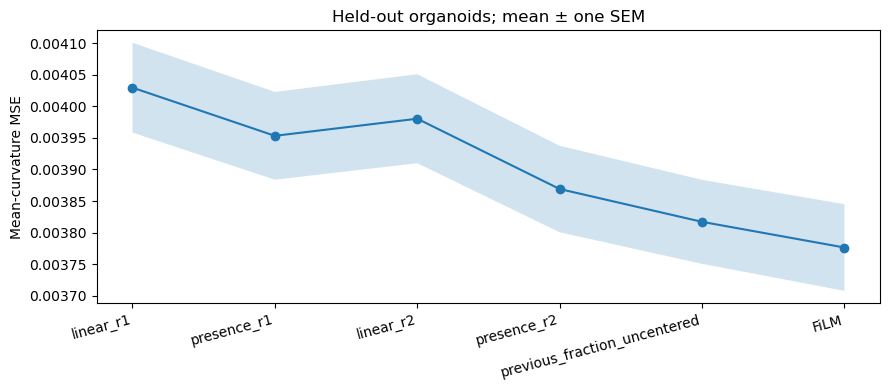

Saved models, baselines, exact splits and settings: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/simple_fate_energy_training/all_sources_linear_presence_20260930_153914


In [5]:
rows = []
for split in membership:
    fold = split['fold']
    samples = graph_samples(load_bundle(RUN_DIR/f'inputs/fold_{fold}_mean')['groups']['val'], 2)
    for record in [r for r in records if r['fold']==fold]:
        model = load_bundle(RUN_DIR/record['bundle'])['model']
        mse = energy_mse(model, samples, device=DEVICE)
        rows.extend(dict(name=record['name'], fold=fold, organoid_str=s['organoid_str'], N=s['N'], mse=float(v)) for s,v in zip(samples,mse))
scores = pd.DataFrame(rows)
scores.to_csv(RUN_DIR/'validation_mse.csv', index=False)
previous = pd.read_csv(source.directory/'validation_mse.csv')
previous = previous[previous.name=='FiLM'].copy()
fraction_run = PROJECT_ROOT/'training_results/pooled_interaction_training/centered_vs_uncentered_20260930_112935'
fraction_scores = pd.read_csv(fraction_run/'validation_mse.csv')
fraction_scores = fraction_scores[fraction_scores.name=='pooled_uncentered'].copy()
fraction_scores['name'] = 'previous_fraction_uncentered'
combined = pd.concat([scores, fraction_scores, previous], ignore_index=True)
summary = combined.groupby('name').mse.agg(['mean','sem']).reindex(SETTINGS['variants']+['previous_fraction_uncentered','FiLM'])
fig,ax = plt.subplots(figsize=(9,4))
x = np.arange(len(summary))
ax.plot(x,summary['mean'],'o-')
ax.fill_between(x,summary['mean']-summary['sem'],summary['mean']+summary['sem'],alpha=.2)
ax.set_xticks(x,summary.index,rotation=15,ha='right')
ax.set(ylabel='Mean-curvature MSE',title='Held-out organoids; mean ± one SEM')
fig.tight_layout()
fig.savefig(RUN_DIR/'validation_mse.png',dpi=160)
plt.show()
print('Saved models, baselines, exact splits and settings:',RUN_DIR)
